In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Correct the file path
file_path = 'Excel_data/Filling_Mean_STD - Copy.csv'
# file_path = 'Excel_data/Filling_Mean_Pulsatile.csv'
# Read the CSV file without headers
data = pd.read_csv(file_path, header=None)

In [27]:
data.columns = ['Index', 'Column1', 'Column2', 'Column3', 'Column4', 'Column5']

# If you know which columns are 'x' and 'y', rename them accordingly:
# For example, if 'Column1' is x and 'Column2' is y:
data.columns = ['Index', 'Mean', 'StdDev', 'Other1', 'Other2', 'Other3']

# Check the columns to confirm they're correct
print(data.columns)  # This will help you ensure the columns are renamed

Index(['Index', 'Mean', 'StdDev', 'Other1', 'Other2', 'Other3'], dtype='object')


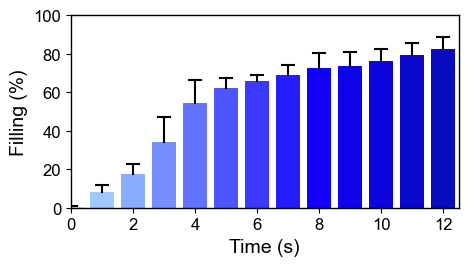

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_colors = 16
# Define the colormap from light blue to dark green
# colormap = mcolors.LinearSegmentedColormap.from_list('red', [(1, 0.8, 0.8), (0.5, 0, 0.5)])
# Use the main_color and create a colormap from a light version to main_color
# main_color = "#590976"
# light_color = mcolors.to_rgba(main_color, alpha=0.5)  # light version with alpha
# colormap = mcolors.LinearSegmentedColormap.from_list('main', [light_color, main_color])
# Use a more vibrant blue gradient for a "shining" effect
colormap = mcolors.LinearSegmentedColormap.from_list(
    "shiny_blue_gradient",
    ["#B3E6FF", "#1100FF", "#00157F"]  # light cyan-blue to vivid blue to deep blue
)
# Normalize the data
max_value = max(data['Mean'])
normalized_mean = (data['Mean'] / (max_value + 100000)) * 100
normalized_stddev = (data['StdDev'] / (max_value + 100000)) * 100

# Generate the gradient of colors
colors = [colormap(i / num_colors) for i in range(num_colors)]

# num_bars = len(data)
# num_steps = (num_bars + 1) // 2  # round up for odd number of bars
# step_colors = [colormap(i / (num_steps - 1)) for i in range(num_steps)]
# colors = [step_colors[i // 2] for i in range(num_bars)]



# Custom color list to match LIVE/DEAD assay figure
# colors = ['#000080', '#0000CD', '#4169E1', '#7B68EE', '#87CEFA', '#ADD8E6']





# Plot the bar chart with the updated colors
plt.figure(figsize=(5, 2.5))
# Plot the bar chart with the updated colors
# plt.grid(True, alpha=0.2, zorder=0,linestyle='-')
# plt.bar(data['Index'][::1], normalized_mean[::1], yerr=normalized_stddev[::1], capsize=5, color=colors, width=4)# , edgecolor='black'
# bars = plt.bar(data['Index'], normalized_mean, color=colors, width=4, edgecolor='black')

# # Add error bars on top only
# # Specifying yerr with upper limits only
# upper_limits = normalized_stddev
# lower_limits = [0] * len(normalized_stddev)  # No lower error
# plt.errorbar(data['Index'], normalized_mean, yerr=[lower_limits, upper_limits], fmt=' ', capsize=5, ecolor='black')

bars = plt.bar(data['Index'], normalized_mean, color=colors, width=0.8)

# Manually add error bars with caps on top only
capsize = 1.5  # size of the error bar cap in points
capwidth = capsize / 72. * plt.gcf().dpi / plt.gcf().get_size_inches()[0]  # convert points to figure coordinates

for i, (x, mean, error) in enumerate(zip(data['Index'], normalized_mean, normalized_stddev)):
    # Draw the error bars
    plt.plot([x, x], [mean, mean + error], color='black')  # Vertical line for error
    
    # Draw the cap
    plt.plot([x - capwidth / 2, x + capwidth / 2], [mean + error, mean + error], color='black')  # Horizontal line for cap
    # Set the bounding box (spines) to black
    for spine in plt.gca().spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
# Adding labels and title

# Set x-ticks and y-ticks explicitly for better control
xticks = [0, 2, 4, 6, 8, 10, 12]
plt.xticks(xticks, [str(x) for x in xticks], fontsize=12, fontname='Arial')
plt.xlim(left=min(data['Index'].dropna()), right=12.5)
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.xlabel('Time (s)', fontname='Arial', fontsize=14)
plt.ylabel('Filling (%)', fontname='Arial', fontsize=14)
# plt.title('Pulsatile filling', fontname='Arial', fontsize=14)
# plt.title('Continous filling', fontname='Arial', fontsize=14)
plt.ylim(0, 100)
plt.savefig('figure.png', dpi=300,bbox_inches='tight')

# Show plot
plt.show()


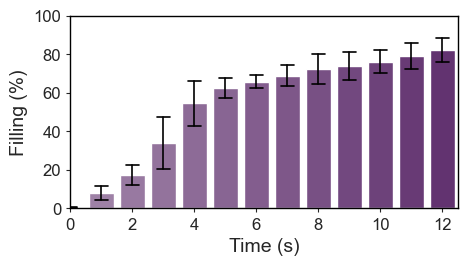

In [246]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load your data
data = pd.read_csv('Excel_data/Filling_Mean_STD - Copy.csv', header=None)
data.columns = ['Index', 'Mean', 'StdDev', 'Other1', 'Other2', 'Other3']

# Gradient color
# main_color = "#A709E0"
# light_color = mcolors.to_rgba(main_color, alpha=0.5)
# colormap = mcolors.LinearSegmentedColormap.from_list('main', [light_color, main_color])
num_colors = 13
# colors = [colormap(i / num_colors) for i in range(num_colors)]

# num_colors = 16
# Define the colormap from light blue to dark green
# colormap = mcolors.LinearSegmentedColormap.from_list('red', [(1, 0.8, 0.8), (0.5, 0, 0.5)])
# Use the main_color and create a colormap from a light version to main_color
main_color = "#481158E2"
light_color = mcolors.to_rgba(main_color, alpha=0.5)  # light version with alpha
colormap = mcolors.LinearSegmentedColormap.from_list('main', [light_color, main_color])


# Normalize
max_value = max(data['Mean'])
normalized_mean = (data['Mean'] / (max_value + 100000)) * 100
normalized_stddev = (data['StdDev'] / (max_value + 100000)) * 100
colors = [colormap(i / num_colors) for i in range(num_colors)]
# Plot setup
plt.figure(figsize=(5, 2.5))
bars = plt.bar(data['Index'], normalized_mean, color=colors, width=0.8)

# Manual error bars with BOTH top & bottom caps, THICK
capsize = 1.5
capwidth = capsize / 72. * plt.gcf().dpi / plt.gcf().get_size_inches()[0]

for i, (x, mean, error) in enumerate(zip(data['Index'], normalized_mean, normalized_stddev)):
    # SD vertical line
    plt.plot([x, x], [mean - error, mean + error], color='black', linewidth=1.2)  # THICKER LINE
    # Caps
    plt.plot([x - capwidth / 2, x + capwidth / 2], [mean + error, mean + error], color='black', linewidth=1.2)
    plt.plot([x - capwidth / 2, x + capwidth / 2], [mean - error, mean - error], color='black', linewidth=1.2)

# Ticks — your style
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='both', which='both', direction='out', length=3, width=0.8,
                labelsize=12, bottom=True, top=False, left=True, right=False)

# Spines
for spine in plt.gca().spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)
    # Set custom x-tick positions and labels
    # Set xticks as before
    xticks = [0, 2, 4, 6, 8, 10, 12]
    plt.xticks(xticks, [str(x) for x in xticks], fontsize=12, fontname='Arial')
    # Reduce the right margin by setting xlim to just past the last bar
    plt.xlim(left=min(data['Index'].dropna()), right=12.5)
    plt.xticks(xticks, [str(x) for x in xticks], fontsize=12, fontname='Arial')
# Labels
plt.xlabel('Time (s)', fontname='Arial', fontsize=14)
plt.ylabel('Filling (%)', fontname='Arial', fontsize=14)
# plt.title('Continous filling', fontname='Arial', fontsize=14)
plt.ylim(0, 100)

# Save and show
plt.savefig('figure_final_your_style.png', dpi=600, bbox_inches='tight')
plt.show()


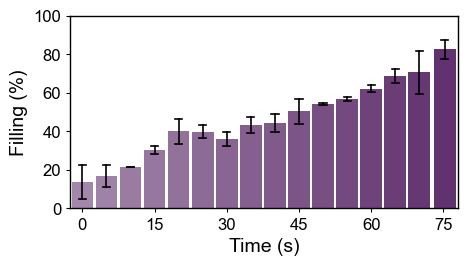

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load the PULSATILE data
data = pd.read_csv('Excel_data/Filling_Mean_Pulsatile.csv', header=None)
data.columns = ['Index', 'Mean', 'StdDev', 'Other1', 'Other2', 'Other3']

# Gradient color (same as before)

colormap = mcolors.LinearSegmentedColormap.from_list(
    "shiny_blue_gradient",
    ["#B3E6FF", "#1100FF", "#00157F"]  # light cyan-blue to vivid blue to deep blue
)

# main_color = "#481158E2"
# light_color = mcolors.to_rgba(main_color, alpha=0.5)
# colormap = mcolors.LinearSegmentedColormap.from_list('main', [light_color, main_color])
num_colors = 16
colors = [colormap(i / num_colors) for i in range(num_colors)]

# Normalize values
max_value = max(data['Mean'])
normalized_mean = (data['Mean'] / (max_value + 100000)) * 100
normalized_stddev = (data['StdDev'] / (max_value + 100000)) * 100

# Plot
plt.figure(figsize=(5, 2.5))
bars = plt.bar(data['Index'], normalized_mean, color=colors, width=4.5)

# Error bars (top and bottom caps, thick)
capsize = 1.5
# capwidth = capsize / 72. * plt.gcf().dpi / plt.gcf().get_size_inches()[0]
capwidth = 1.5
for x, mean, error in zip(data['Index'], normalized_mean, normalized_stddev):
    plt.plot([x, x], [mean - error, mean + error], color='black', linewidth=1.2)
    plt.plot([x - capwidth / 2, x + capwidth / 2], [mean + error, mean + error], color='black', linewidth=1.2)
    plt.plot([x - capwidth / 2, x + capwidth / 2], [mean - error, mean - error], color='black', linewidth=1.2)

# Ticks and labels
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='both', which='both', direction='out', length=3, width=0.8,
                labelsize=12, bottom=True, top=False, left=True, right=False)

# Spines
for spine in plt.gca().spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)
    # Set custom x-tick positions and labels, ending at 75
    xticks = [0, 15, 30, 45, 60, 75]
    plt.xticks(xticks, [str(x) for x in xticks], fontsize=12, fontname='Arial')
    # Set xlim to just past the last bar, e.g., 78 (not exactly at 75)
    plt.xlim(left=-2.5, right=78)
# Axis labels
plt.xlabel('Time (s)', fontname='Arial', fontsize=14)
plt.ylabel('Filling (%)', fontname='Arial', fontsize=14)
# plt.title('Pulsatile filling', fontname='Arial', fontsize=14)
plt.ylim(0, 100)

# Save and show
plt.savefig('figure_pulsatile_final.png', dpi=600, bbox_inches='tight')
plt.show()

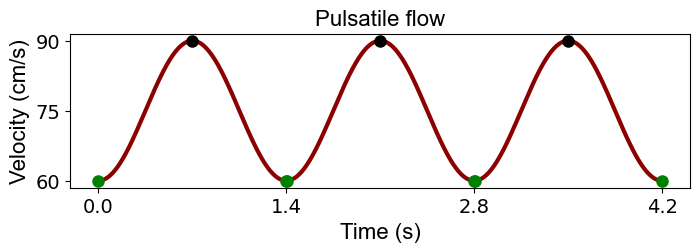

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the sine wave
min_val = 60
max_val = 90
mid = (max_val + min_val) / 2
amplitude = (max_val - min_val) / 2
period = 1.4  # period of the sine wave in seconds
frequency = 1 / period  # frequency of the sine wave

# Time array from 0 to 2.8 seconds (to show a few cycles)
t = np.linspace(0, 4.2, 1000)

# Adjust sine wave calculation to match the frequency
# Adding a phase shift of -π/2 to start the wave from the minimum
y = mid + amplitude * np.sin(2 * np.pi * frequency * t - np.pi / 2)

# Set up figure and axes
fig, ax = plt.subplots(figsize=(8,2))

# Plot the sine wave with improved style
ax.plot(t, y, color='darkred', linestyle='-', linewidth=3)

# Set x and y axis labels
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')

# Set plot title
ax.set_title('Pulsatile flow', fontsize=16, fontname='Arial')

# Set grid lines
# ax.grid(True, linestyle='--', alpha=1)

# Function to detect minima and maxima
def detect_minima(y):
    indices = np.argwhere((np.roll(y, 3) > y) & (np.roll(y, -2) > y))
    return indices.flatten()

def detect_maxima(y):
    indices = np.argwhere((np.roll(y, 1) < y) & (np.roll(y, -2) < y))
    return indices.flatten()

min_indices = detect_minima(y)
max_indices = detect_maxima(y)

# Highlight minima
for index in min_indices:
    ax.plot(t[index], y[index], 'o', color='green', markersize=8)  # Mark minimum points

# Highlight maxima
for index in max_indices:
    ax.plot(t[index], y[index], 'o', color='black', markersize=8)  # Mark maximum points

# Set the x-axis ticks
ax.set_xticks(np.arange(0, 4.3, 1.4))  # x-ticks from 0 to 2.8 every 0.7
ax.set_yticks(np.arange(60, 91, 15))  # y-ticks from 60 to 90 every 10
ax.tick_params(axis='y', labelsize=14) 
ax.tick_params(axis='x', labelsize=14) # Increase y-tick font size
# Show the plot
plt.savefig('Pulsatile_velocity', dpi=300,bbox_inches='tight')
plt.show()






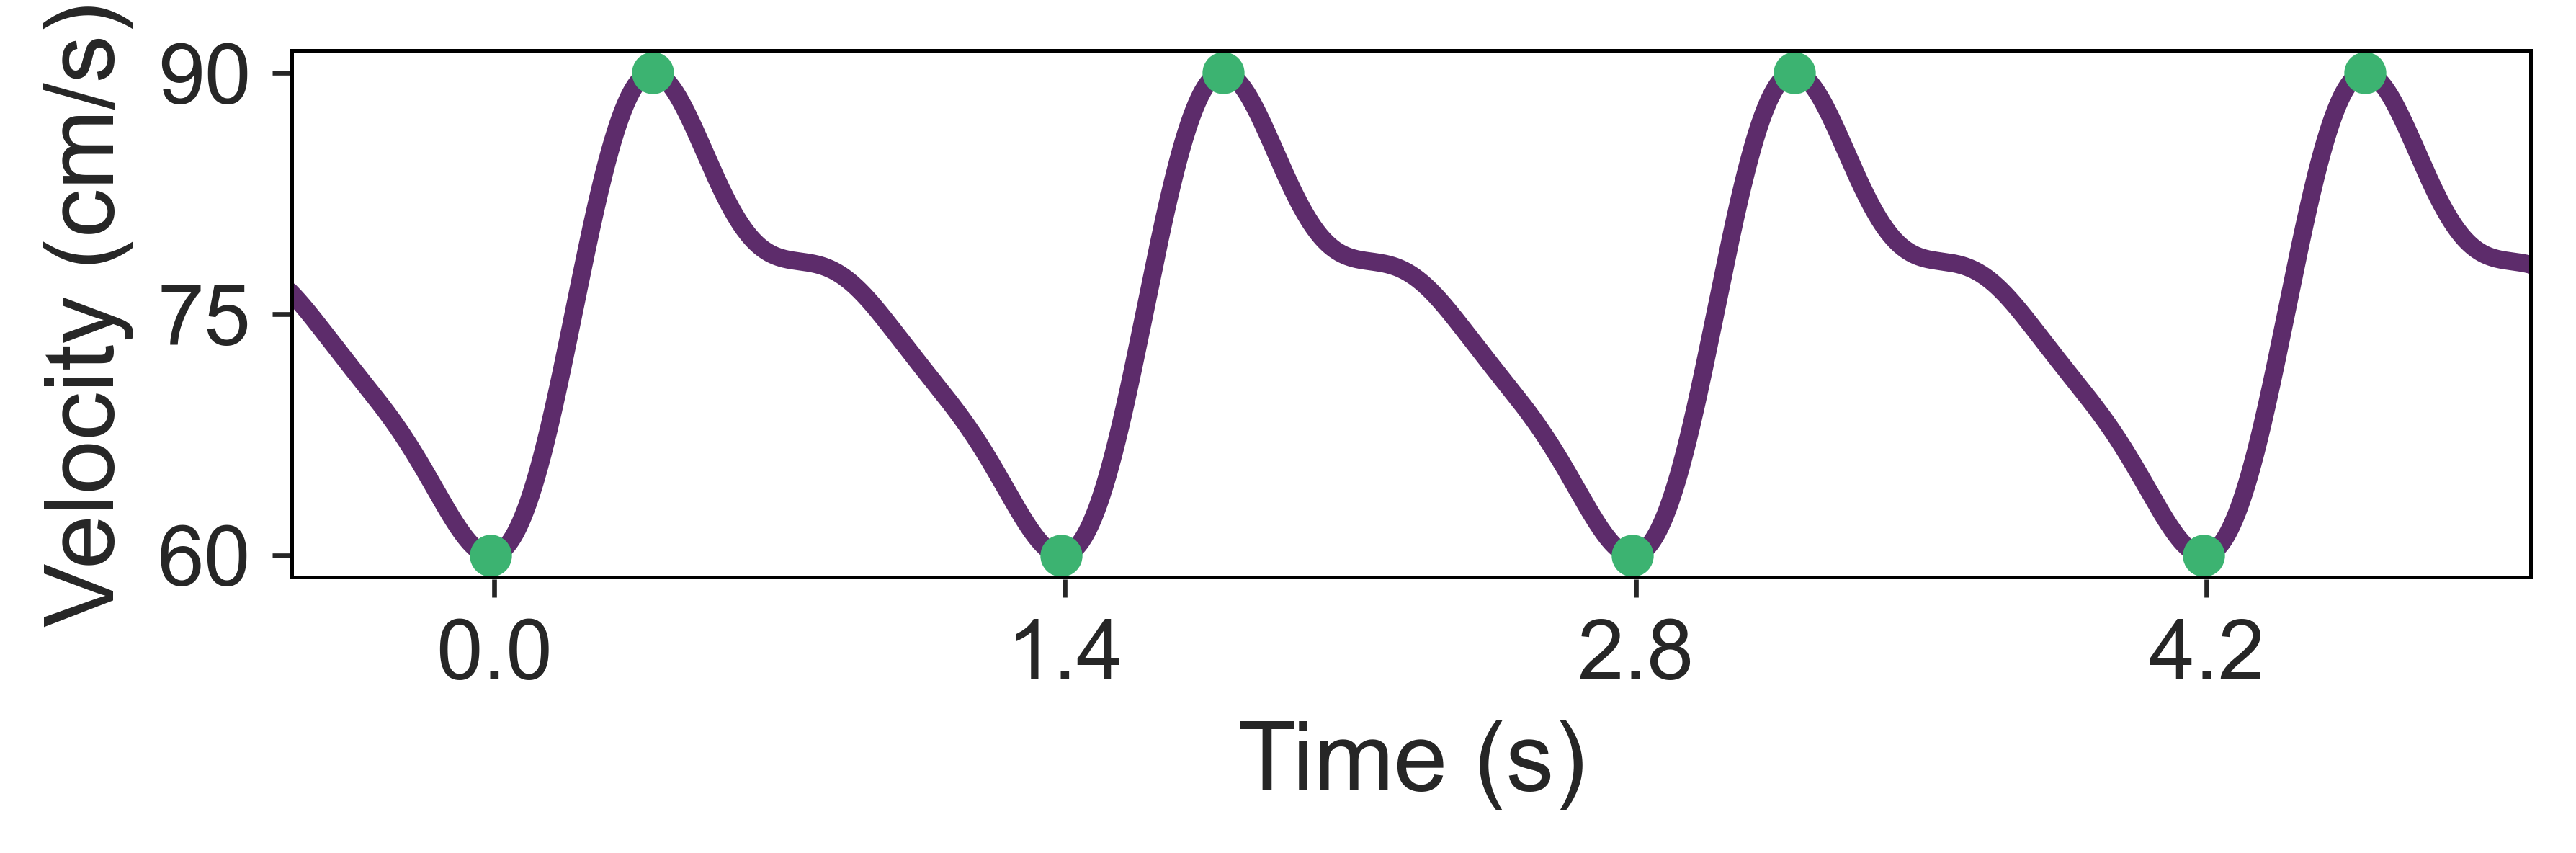

In [245]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.patches import Rectangle

# === Aesthetic Constants ===
main_color = "#481158E2"       # Deep purple
trough_color = "#3CB371"       # Medium sea green
peak_color = "#3CB371"         # Also green for consistency

# Sampling and time vector (from -1s to 5s)
fs = 1000
t = np.linspace(-1, 5.0, int(6.0 * fs))
f0 = 1 / 1.4  # ~1.4s period

# Shift time to align first trough with t ≈ 0
phase_offset = 0.2  # ⬅️ tweak this if needed
t_shifted = t - phase_offset

# Generate waveform
y = (0.6 * np.sin(2 * np.pi * f0 * t_shifted) +
     0.3 * np.sin(4 * np.pi * f0 * t_shifted + 0.2) +
     0.1 * np.sin(6 * np.pi * f0 * t_shifted - 0.2))

# Normalize to range 60–90 cm/s
y = (y - y.min()) / (y.max() - y.min())
y = 60 + y * 30

# Plot setup
fig, ax = plt.subplots(figsize=(6, 2), dpi=600)
ax.plot(t, y, color=main_color, linewidth=3)

# Find peaks and troughs
peaks, _ = find_peaks(y, distance=fs * 0.5)
troughs, _ = find_peaks(-y, distance=fs * 0.5)

# Plot troughs
ax.plot(t[troughs], y[troughs], 'o', color=trough_color, markersize=6, zorder=3)

# Plot peaks (skip if too close to troughs)
for p in peaks:
    if not any(abs(p - t_idx) < 10 for t_idx in troughs):
        ax.plot(t[p], y[p], 'o', color=peak_color, markersize=6, zorder=3)

# Labels and ticks
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')
ax.set_xticks([0.0, 1.4, 2.8, 4.2])
ax.set_yticks([60, 75, 90])
ax.tick_params(axis='both', labelsize=14, direction='out', length=3, width=0.8)

# Axis limits
ax.set_xlim(-0.5, 5)
ax.set_ylim(58.5, 91.5)

# Bounding box
ax.add_patch(Rectangle(
    (ax.get_xlim()[0], ax.get_ylim()[0]),
    ax.get_xlim()[1] - ax.get_xlim()[0],
    ax.get_ylim()[1] - ax.get_ylim()[0],
    linewidth=1.2, edgecolor='black', facecolor='none', zorder=5
))

# Hide top/right spines
for spine in ax.spines.values():
    spine.set_visible(False)
    # Show only left and bottom ticks
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    # Increase font size of x and y tick numbers
    # ax.tick_params(axis='both', labelsize=16)
# Finalize
plt.tight_layout()
plt.savefig('Pulsatile_velocity_final_aligned.png', dpi=600, bbox_inches='tight')
plt.show()


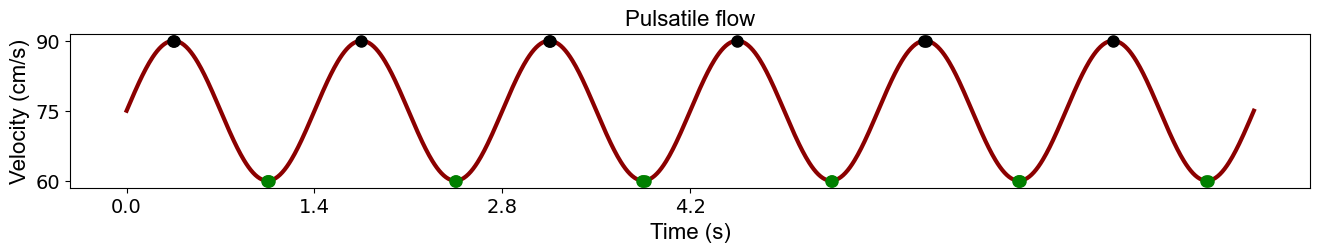

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the sine wave
min_val = 60
max_val = 90
mid = (max_val + min_val) / 2
amplitude = (max_val - min_val) / 2
period = 1.4  # period of the sine wave in seconds
frequency = 1 / period  # frequency of the sine wave

# Time array from 0 to 4.2 seconds (to show a few cycles)
t = np.linspace(0, 8.4, 1000)

# Adjust sine wave calculation to match the frequency
# No phase shift to start the wave from the center
y = mid + amplitude * np.sin(2 * np.pi * frequency * t)

# Set up figure and axes
fig, ax = plt.subplots(figsize=(16, 2))

# Plot the sine wave with improved style
ax.plot(t, y, color='darkred', linestyle='-', linewidth=3)

# Set x and y axis labels
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')

# Set plot title
ax.set_title('Pulsatile flow', fontsize=16, fontname='Arial')

# Function to detect minima and maxima
def detect_minima(y):
    indices = np.argwhere((np.roll(y, 3) > y) & (np.roll(y, -2) > y))
    return indices.flatten()

def detect_maxima(y):
    indices = np.argwhere((np.roll(y, 1) < y) & (np.roll(y, -2) < y))
    return indices.flatten()

min_indices = detect_minima(y)
max_indices = detect_maxima(y)

# Highlight minima
for index in min_indices:
    ax.plot(t[index], y[index], 'o', color='green', markersize=8)  # Mark minimum points

# Highlight maxima
for index in max_indices:
    ax.plot(t[index], y[index], 'o', color='black', markersize=8)  # Mark maximum points

# Set the x-axis ticks
ax.set_xticks(np.arange(0, 4.3, 1.4))  # x-ticks from 0 to 4.2 every 1.4
ax.set_yticks(np.arange(60, 91, 15))  # y-ticks from 60 to 90 every 15
ax.tick_params(axis='y', labelsize=14) 
ax.tick_params(axis='x', labelsize=14)

# Save and show the plot
plt.savefig('ON_OFF_US', dpi=300, bbox_inches='tight')
plt.show()


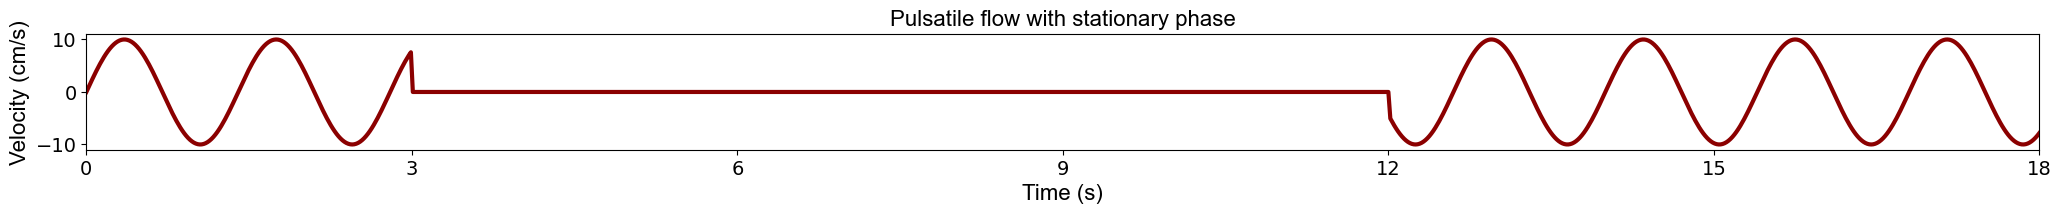

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the sine wave
min_val = -10
max_val = 10
mid = (max_val + min_val) / 2
amplitude = (max_val - min_val) / 2
period = 1.4  # period of the sine wave in seconds
frequency = 1 / period  # frequency of the sine wave

# Time array from 0 to 8.4 seconds
t = np.linspace(0, 18, 1000)

# Sine wave calculation to match the frequency
y_sine1 = mid + amplitude * np.sin(2 * np.pi * frequency * t[t < 3])
y_flat = np.full(len(t[(t >= 3) & (t <= 12)]), mid)  # Flat section at midpoint level
y_sine2 = mid + amplitude * np.sin(2 * np.pi * frequency * t[t > 12])

# Combine all sections
y = np.concatenate((y_sine1, y_flat, y_sine2))

# Set up figure and axes
fig, ax = plt.subplots(figsize=(25.2, 1.5))

# Plot the combined wave
ax.plot(t, y, color='darkred', linestyle='-', linewidth=3)

# Set x and y axis labels
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')

# Set plot title
ax.set_title('Pulsatile flow with stationary phase', fontsize=16, fontname='Arial')
ax.set_xlim(0, 18)

# Set the x-axis and y-axis ticks
ax.set_xticks(np.arange(0, 19, 3))  # x-ticks to reflect all segments
ax.set_yticks(np.arange(-10, 11, 10))  # y-ticks from 60 to 90 every 15
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Save and show the plot
plt.savefig('ON_OFF_US', dpi=300, bbox_inches='tight')
plt.show()

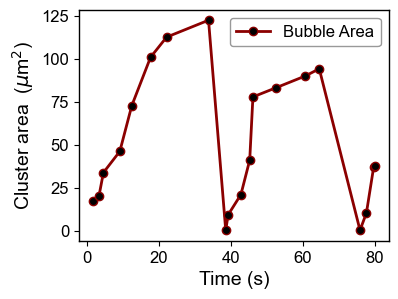

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 12

# Read data from CSV file
data1 = pd.read_csv('Excel_data/Bubble_shooting.csv')
data1.columns = ['A', 'B']  # Correctly labeled columns as 'A' for time and 'B' for bubble area

# Extract the time and bubble area columns
time = data1['A']
bubble_area = data1['B']

# Plot the data
plt.figure(figsize=(4, 3), facecolor='white')  # Ensure white background for the figure
plt.plot(time, bubble_area, label='Bubble Area', marker='o', linestyle='-', color='darkred', linewidth=2, markerfacecolor='black', markersize=6)

# Set the x-axis label with enhanced formatting
plt.xlabel('Time (s)', fontsize=14, backgroundcolor='white')

# Set the y-axis label with enhanced formatting
plt.ylabel('Cluster area  ($\mu$m$^2$)', fontsize=14, backgroundcolor='white')

# Set the size of the tick labels on both axes
plt.tick_params(axis='both', which='major', labelsize=12)

# Darken the box around the plot
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['bottom'].set_color('black')

# Add the legend with a clean background
plt.legend(facecolor='white', framealpha=0.4, edgecolor='black')

# Turn off the grid
plt.grid(False)

# Save the plot with high resolution and tight bounding box
plt.savefig('Bubble_shooting', dpi=300, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()






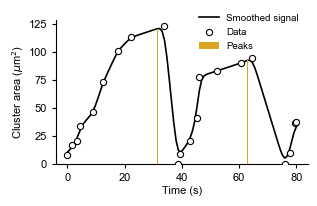

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from matplotlib import rcParams

# Set global font to Arial (fallback to sans-serif if unavailable)
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8

# Load your data
data = pd.read_csv('Excel_data/Bubble_shooting.csv', names=['time', 'area'])
x = data['time']
y = data['area']

# Interpolate and smooth (minimal smoothing to preserve real shape)
interp_func = interp1d(x, y, kind='slinear')
x_interp = np.linspace(x.min(), x.max(), 100)
y_interp = interp_func(x_interp)
y_smooth = gaussian_filter1d(y_interp, sigma=1.2)

# Peak detection
peaks, _ = find_peaks(y_smooth, distance=6, prominence=2)
peak_times = x_interp[peaks]
peak_values = y_smooth[peaks]

# Plot: publication-grade
fig, ax = plt.subplots(figsize=(3.2, 2.1))  # Science-friendly panel size

# Smoothed curve
ax.plot(x_interp, y_smooth, color='black', linewidth=1.2, label='Smoothed signal')

# Original points
ax.scatter(x, y, facecolors='white', edgecolors='black', s=20, linewidth=0.8, zorder=3, label='Data')

# Peaks as golden bars
ax.bar(peak_times, peak_values, width=0.5, color='goldenrod', edgecolor='none', zorder=2, label='Peaks')

# No top/right spines (clean aesthetic)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Axis labels
ax.set_xlabel('Time (s)', labelpad=2)
ax.set_ylabel('Cluster area ($\mu$m$^2$)', labelpad=2)

# Ticks and layout
ax.tick_params(length=3, width=0.8, labelsize=8)
ax.legend(loc='upper right', frameon=False, fontsize=7, bbox_to_anchor=(1, 1.1))

# Tight layout
plt.tight_layout(pad=1.0)

# Save high-quality outputs
plt.savefig('Figure_Peaks_Science.pdf', dpi=600)
plt.savefig('Figure_Peaks_Science.png', dpi=600)
plt.show()


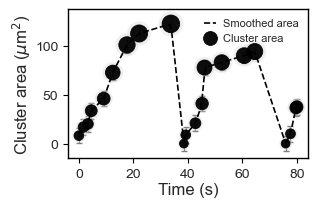

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from matplotlib import rcParams

# Font settings
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8

# Load data
data = pd.read_csv('Excel_data/Bubble_shooting.csv', names=['time', 'area'])
x = data['time'].to_numpy()
y = data['area'].to_numpy()

# Smooth line
interp_func = interp1d(x, y, kind='slinear')
x_interp = np.linspace(x.min(), x.max(), 300)
y_smooth = gaussian_filter1d(interp_func(x_interp), sigma=1.5)

# Marker sizes
size_scaled = 40 + 120 * (y - y.min()) / (y.max() - y.min())
halo_scaled = size_scaled * 2  # uncertainty halo

# Fixed ±8 μm² error bars
yerr_fixed = np.full_like(y, 8)

# Colors
main_color = "#8f3aad"
halo_color = "#eac4f6"

# Plot
fig, ax = plt.subplots(figsize=(3.2, 2.1))  # Science panel size
ax.set_facecolor('white')

# Smoothed line
ax.plot(x_interp, y_smooth, color='black', linewidth=1.2, linestyle='--', label='Smoothed area')

# Error bars
ax.errorbar(x, y, yerr=yerr_fixed, fmt='none',
            ecolor='grey', elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=0)

# Halo
ax.scatter(x, y, s=halo_scaled, color='lightgrey', edgecolors='none', alpha=0.35, zorder=1)

# # Main bubbles
# ax.scatter(x, y, s=size_scaled, color=main_color, edgecolors='black',
#            linewidth=0.6, alpha=0.95, zorder=2, label='Cluster area')
# Main bubbles
ax.scatter(x, y, s=size_scaled, color='black', edgecolors='black',
           linewidth=0.6, alpha=0.95, zorder=2, label='Cluster area')
# Axes style
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# ✅ Enable ticks on both x and y axes
# Ensure ticks are visible on all sides and not hidden by overlapping elements
ax.tick_params(axis='both', direction='out', length=3.5, width=0.8, labelsize=10, color='black')
ax.xaxis.set_tick_params(bottom=True, top=False)
ax.yaxis.set_tick_params(left=True, right=False)
# Bring ticks/spines to front if needed
ax.set_axisbelow(False)

# Labels
ax.set_xlabel('Time (s)', labelpad=1.5)
ax.set_ylabel('Cluster area ($\mu$m$^2$)', labelpad=1.5)

# Legend
ax.legend(loc='upper right', frameon=False, fontsize=7, handlelength=1.2)
# Match legend font size to tick labels
legend = ax.get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(8)
plt.tight_layout(pad=1.0)
plt.savefig('Figure_Bubbles_ErrorCaps_WithTicks.png', dpi=600)
plt.show()


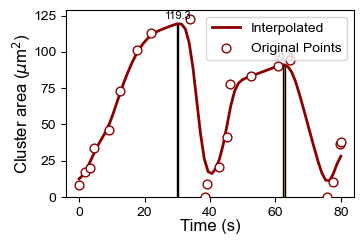

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from matplotlib import rcParams

# Set global font
rcParams['font.family'] = 'Arial'

# Load data
data = pd.read_csv('Excel_data/Bubble_shooting.csv', names=['time', 'area'])
x = data['time']
y = data['area']

# Interpolate and smooth
interp_func = interp1d(x, y, kind='slinear')
x_interp = np.linspace(x.min(), x.max(), 70)
y_interp = interp_func(x_interp)
y_smooth = gaussian_filter1d(y_interp, sigma=1.5)

# Detect peaks
peaks, _ = find_peaks(y_smooth, distance=8, prominence=2.5)
peak_times = x_interp[peaks]
peak_values = y_smooth[peaks]

# Plot
plt.figure(figsize=(3.8,2.6))  # Small figure, tight layout

plt.plot(x_interp, y_smooth, color='darkred', linewidth=2, label='Interpolated')
plt.scatter(x, y, facecolors='white', edgecolors='darkred', s=40, label='Original Points', zorder=3)
plt.bar(peak_times, peak_values, width=0.4, color='goldenrod', edgecolor='black')

# Annotate peaks
for xt, yt in zip(peak_times, peak_values):
    plt.text(xt, yt + 2, f'{yt:.1f}', ha='center', va='bottom', fontsize=8)

# Axis labels closer to axis
plt.xlabel('Time (s)', fontsize=12, labelpad=0.1)
plt.ylabel('Cluster area ($\mu$m$^2$)', fontsize=12, labelpad=0.1)
plt.tick_params(labelsize=10)

# Legend inside
plt.legend(loc='upper right', fontsize=10, frameon=True)

# Tighter layout (prevent extra white space)
plt.tight_layout()

# Save high-quality image without too much white space
plt.savefig('smoothed_peaks_clean_final.png', dpi=300)

plt.show()


C:\Users\M4\AppData\Local\Temp\ipykernel_16860\46358134.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(x=df['Distance'], y=df['Velocity'], yerr=df['StdDev'], fmt='-o', capsize=5, ecolor='lightblue', elinewidth=2,
C:\Users\M4\AppData\Local\Temp\ipykernel_16860\46358134.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x=df['Distance'], y=df['Velocity'], yerr=df['StdDev'], fmt='-o', capsize=5, ecolor='lightblue', elinewidth=2,


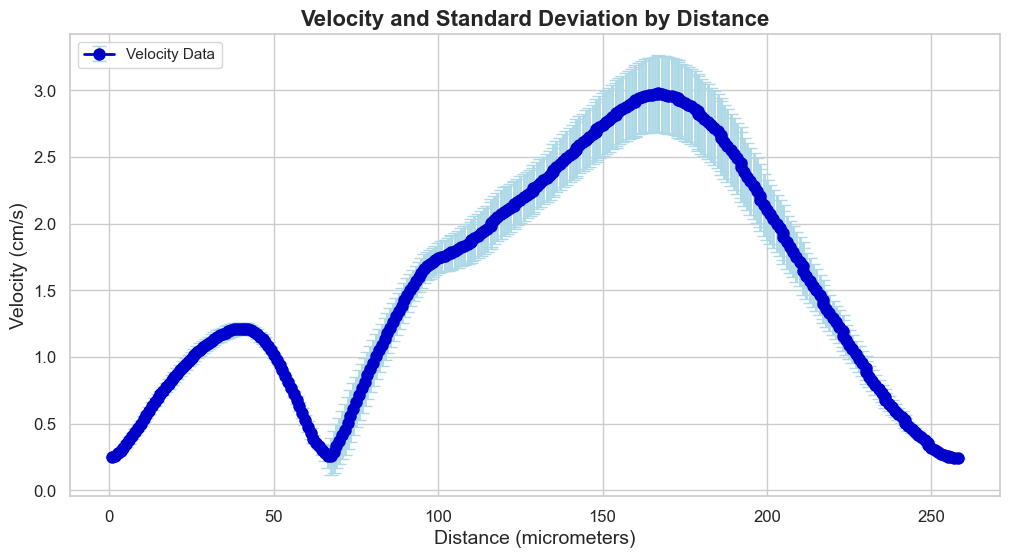

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('Excel_data/PIV_Velocity_Vortex_center.csv')
df.columns = ['Distance', 'Velocity', 'StdDev']

# Convert Distance from meters to micrometers
df['Distance'] = df['Distance'] * 1_000_000  # 1 meter = 1,000,000 micrometers

# Convert Velocity from m/s to mm/s
df['Velocity'] = df['Velocity'] * 1_00  # 1 m/s = 1,00 cm/s

# Convert Standard Deviation from m/s to mm/s
df['StdDev'] = df['StdDev'] * 1_00  # scaling standard deviation

# Set the seaborn style
sns.set(style="whitegrid")

# Create the plot using Matplotlib directly for handling the error bars
plt.figure(figsize=(12, 6))
plt.errorbar(x=df['Distance'], y=df['Velocity'], yerr=df['StdDev'], fmt='-o', capsize=5, ecolor='lightblue', elinewidth=2, 
             marker='o', markersize=8, color='mediumblue', linestyle='-', linewidth=2, label='Velocity Data')

# Add titles and labels with improved formatting
plt.title('Velocity and Standard Deviation by Distance', fontsize=16, fontweight='bold')
plt.xlabel('Distance (micrometers)', fontsize=14)
plt.ylabel('Velocity (cm/s)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left')

# Show the plot
plt.show()


c:\ProgramData\anaconda3\python.exe
3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
c:\ProgramData\anaconda3


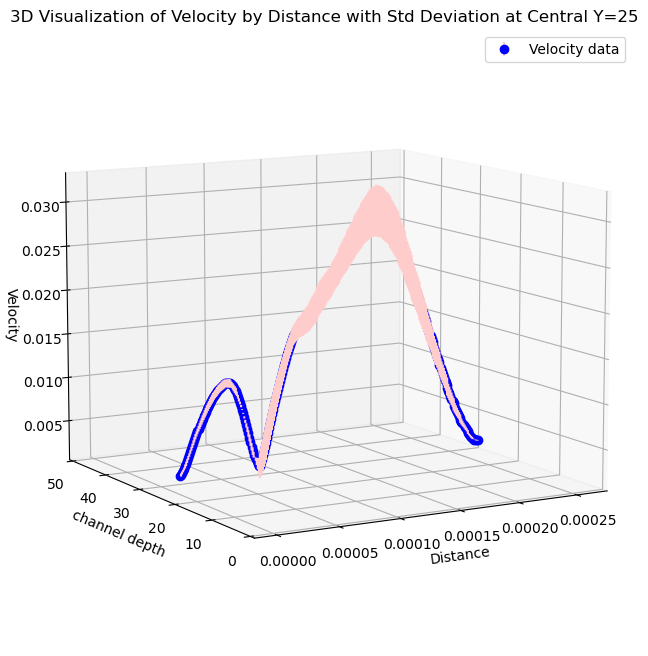

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys

# Read the CSV file
df = pd.read_csv('Excel_data/PIV_Velocity_Vortex_center.csv')
df.columns = ['Distance', 'Velocity', 'StdDev']

# Set up the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Data for plotting
distance = df['Distance']
velocity = df['Velocity']
std_dev = df['StdDev']

# Plotting points with error bars along the z-axis (Velocity)
for i in range(len(distance)):
    # Plotting each point and its standard deviation
    ax.errorbar(distance[i], 25, velocity[i], zerr=std_dev[i], fmt='o', color='blue', ecolor=(1, 0.8, 0.8), label='Velocity data' if i == 0 else "")

# Labeling
ax.set_xlabel('Distance')
ax.set_ylabel('channel depth')
ax.set_zlabel('Velocity')

# Set Y-axis limits to represent the span from 0 to 50
ax.set_ylim([0, 50])

# Title and legend
ax.set_title('3D Visualization of Velocity by Distance with Std Deviation at Central Y=25')
ax.legend()

# Set the view angle for better viewing perspective
ax.view_init(elev=10, azim=240)  # Adjust these angles as needed to get the best view

# Show the plot
print(sys.executable)
print(sys.version)
print(sys.prefix)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = r'C:\Users\mmabo\V_Code\New folder\Aneurysm_filling\Excel_data\soalr results.xlsx'  # Note the raw string literal
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Rename the columns for clarity
df.columns = ['Cell distance', 'PPO OFF', 'PPO ON']

# Remove rows with NaN values in 'Cell distance' column
df_cleaned = df.dropna(subset=['Cell distance'])

# Convert 'Cell distance' column to numeric type to ensure proper plotting
df_cleaned['Cell distance'] = pd.to_numeric(df_cleaned['Cell distance'])

# Plotting the cleaned data with enhanced aesthetics
plt.figure(figsize=(12, 8))
plt.plot(df_cleaned['Cell distance'], df_cleaned['PPO OFF'], marker='o', linestyle='-', linewidth=2, markersize=8, label='PPO OFF')
plt.plot(df_cleaned['Cell distance'], df_cleaned['PPO ON'], marker='s', linestyle='-', linewidth=2, markersize=8, label='PPO ON')

# Adding titles and labels with improved font sizes
plt.xlabel('Cell Distance (m)', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.title('PPO OFF and PPO ON vs Cell Distance', fontsize=16)

# Adding grid for better readability
plt.grid(which='both', linestyle='--', linewidth=0.5)

# Adding a legend with improved font size
plt.legend(fontsize=12)

# Adding tick parameters for better readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the enhanced plot
plt.show()

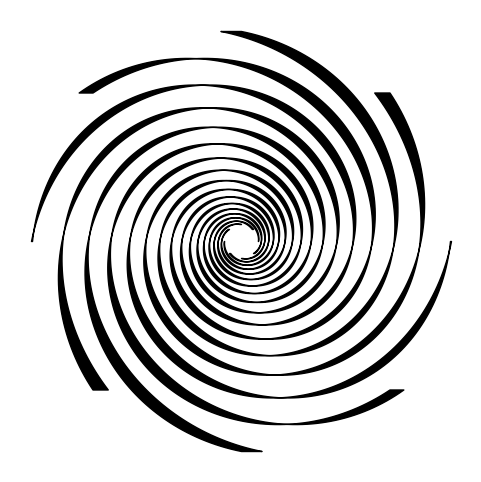

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Number of blades
n_blades = 8  

# Spiral parameters
theta = np.linspace(0, 4 * np.pi, 500)  # Angle from center to outer edge
a = 0.2   # Spiral tightness factor
b = 0.2   # Spiral growth rate

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.axis('off')

# Generate each blade
for i in range(n_blades):
    rotation = i * (2 * np.pi / n_blades)
    r = a * np.exp(b * theta)  # Logarithmic spiral
    x = r * np.cos(theta + rotation)
    y = r * np.sin(theta + rotation)
    
    # Blade shape: draw two offset spirals to give thickness
    blade_offset = np.pi / (n_blades * 4)  # Half-blade width
    x2 = r * np.cos(theta + rotation + blade_offset)
    y2 = r * np.sin(theta + rotation + blade_offset)
    
    ax.fill_betweenx(y, x, x2, color="black")  # Fill blade in black

plt.show()